🚀 Starting standalone forecast (no retraining needed)...
✅ Libraries imported

📁 Upload these 3 files:
   1. Assignment_Data.xlsx (your data)
   2. lstm_gold_forecaster.h5 (your trained model)
   3. best_hyperparameters.txt (optional, for reference)


Saving Assignment_Data.xlsx to Assignment_Data (1).xlsx
Saving best_hyperparameters.txt to best_hyperparameters (1).txt
Saving lstm_gold_forecaster.h5 to lstm_gold_forecaster (1).h5

✅ Files uploaded!

📊 Loading data...
✅ Data loaded: 8774 data points
   Range: $255.55 to $2077.49

🤖 Loading your trained model...
✅ Model loaded successfully!


Model: "LSTM_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,689 (260.50 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)


✅ Detected lookback window: 30 steps

🔄 Preparing data for forecast...
✅ Data normalized
✅ Forecasting function ready

🔮 Generating 30-day future forecast...
✅ Forecast complete!

📊 30-Day Forecast Results:
Last Historical Price:   $2034.23
Day 1 Forecast:          $2031.57
Day 15 Forecast:         $1969.83
Day 30 Forecast:         $1910.41

Price Change:            $-123.82
Percent Change:          -6.09%
Predicted Trend:         📉 DOWNWARD

📈 Creating visualizations...


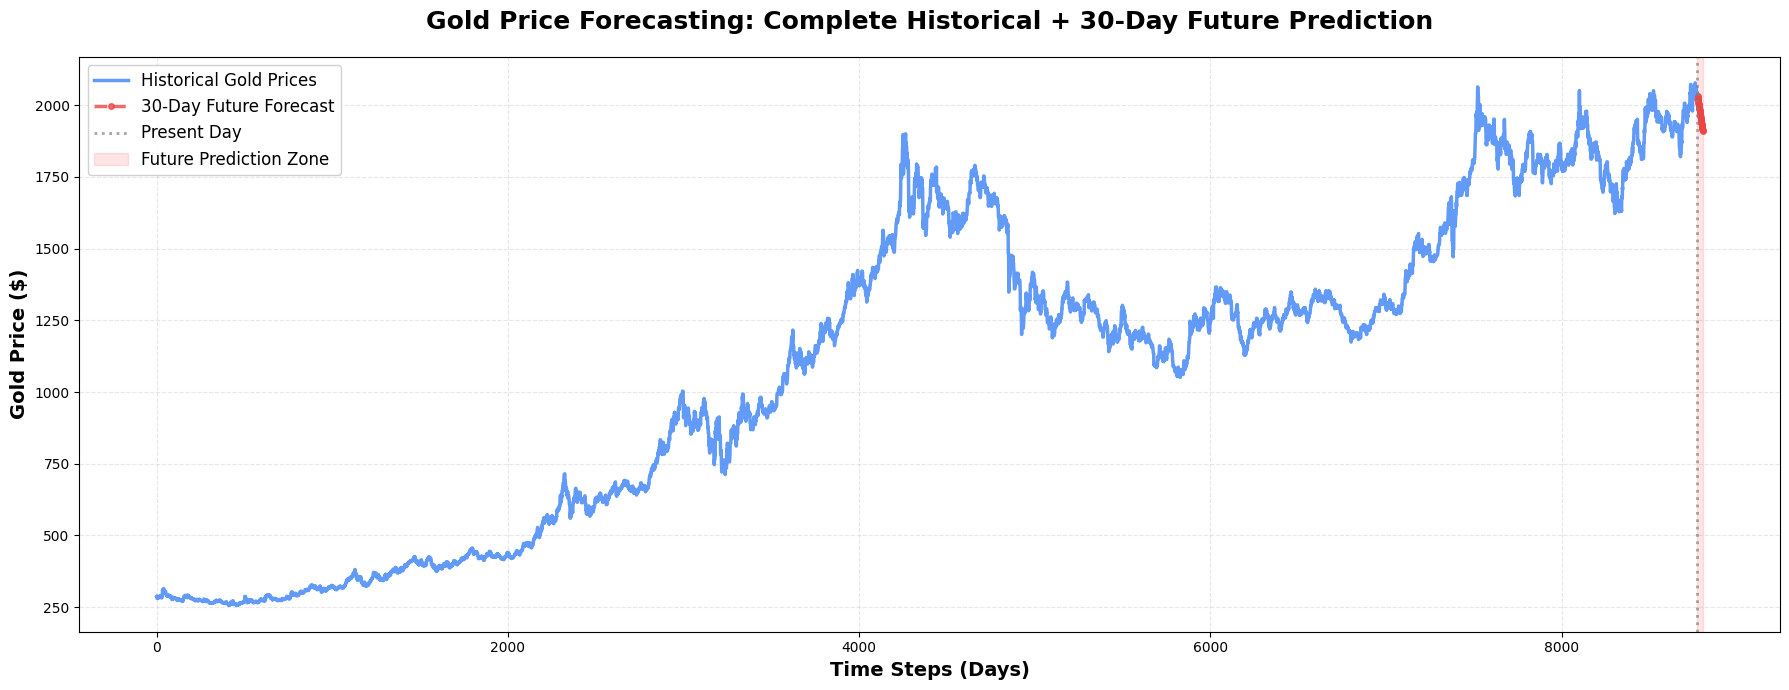

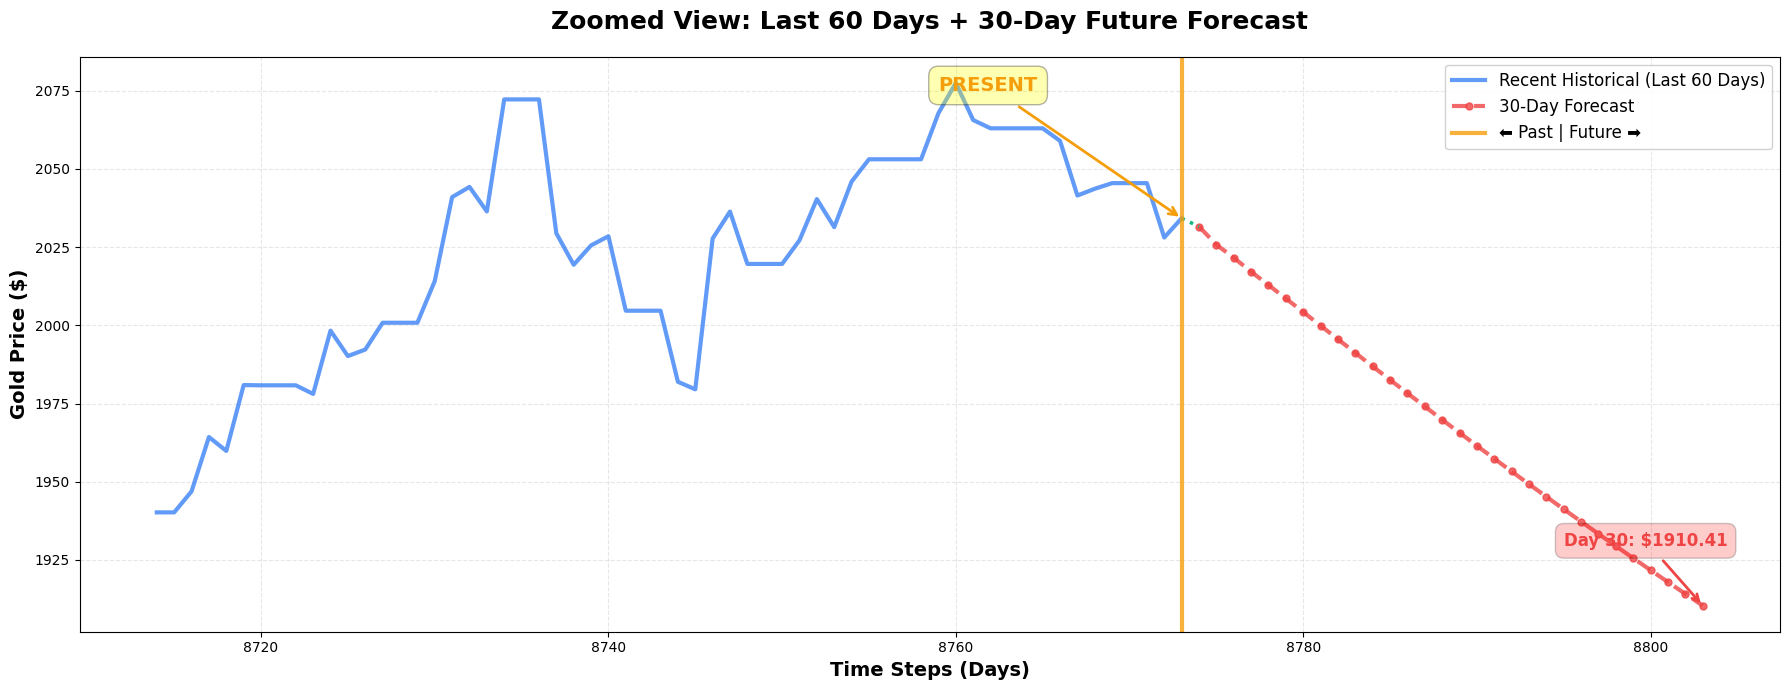


📅 WEEKLY FORECAST BREAKDOWN

📊 Week 1 (Days 1-7):
   Average Price: $2017.40
   Price Range:   $2004.25 - $2031.57

📊 Week 2 (Days 8-14):
   Average Price: $1986.92
   Price Range:   $1974.05 - $1999.90
   Week Change:   $-30.48 (-1.51%)

📊 Week 3 (Days 15-21):
   Average Price: $1957.44
   Price Range:   $1945.21 - $1969.83
   Week Change:   $-29.48 (-1.48%)

📊 Week 4 (Days 22-28):
   Average Price: $1929.50
   Price Range:   $1917.93 - $1941.22
   Week Change:   $-27.94 (-1.43%)

💾 Saving forecast data...
✅ Saved: future_forecast_30days.csv

╔══════════════════════════════════════════════════════════════════╗
║                  30-DAY FORECAST SUMMARY                           ║
╚══════════════════════════════════════════════════════════════════╝

📊 FORECAST DETAILS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Used:          LSTM (30-step lookback)
Forecast Horizon:    30 days
Method:              Recursive multi-step prediction

💰 PRICE PREDICTIONS:
━━━━━━━

In [2]:
# ============================================================================
# STANDALONE 30-DAY FUTURE FORECAST
# Run this WITHOUT retraining - uses your saved model!
# ============================================================================

print("🚀 Starting standalone forecast (no retraining needed)...")

# Install if needed
!pip install -q openpyxl

# ============================================================================
# STEP 1: Import Libraries
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported")

# ============================================================================
# STEP 2: Upload Your Files
# ============================================================================

from google.colab import files

print("\n📁 Upload these 3 files:")
print("   1. Assignment_Data.xlsx (your data)")
print("   2. lstm_gold_forecaster.h5 (your trained model)")
print("   3. best_hyperparameters.txt (optional, for reference)")

uploaded = files.upload()

print("\n✅ Files uploaded!")

# ============================================================================
# STEP 3: Load Data and Model
# ============================================================================

# Load data
print("\n📊 Loading data...")
df = pd.read_excel('Assignment_Data.xlsx', sheet_name='Cmdty')
gold_data = df['Gold'].values

print(f"✅ Data loaded: {len(gold_data)} data points")
print(f"   Range: ${gold_data.min():.2f} to ${gold_data.max():.2f}")

# Load the trained model (with custom objects for compatibility)
print("\n🤖 Loading your trained model...")

# Fix for the 'mse' error - compile=False skips the loss function issue
best_model = keras.models.load_model('lstm_gold_forecaster.h5', compile=False)

# Recompile with standard loss (not needed for prediction, but good practice)
best_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("✅ Model loaded successfully!")
best_model.summary()

# ============================================================================
# STEP 4: Get Hyperparameters (Auto-detect from model)
# ============================================================================

# Extract lookback from model input shape
best_lookback = best_model.input_shape[1]  # Gets the time steps dimension

print(f"\n✅ Detected lookback window: {best_lookback} steps")

# ============================================================================
# STEP 5: Prepare Data (Same as Training)
# ============================================================================

print("\n🔄 Preparing data for forecast...")

# Normalize data (fit on entire dataset for consistency)
scaler = MinMaxScaler(feature_range=(0, 1))
gold_scaled = scaler.fit_transform(gold_data.reshape(-1, 1)).flatten()

print("✅ Data normalized")

# ============================================================================
# STEP 6: Recursive Forecasting Function
# ============================================================================

def forecast_future(model, last_sequence, n_steps, scaler):
    """
    Recursively forecast n_steps into the future.
    """
    predictions = []
    current_sequence = last_sequence.copy()

    for step in range(n_steps):
        # Reshape for model input
        current_input = current_sequence.reshape(1, len(current_sequence), 1)

        # Predict next value
        next_pred_scaled = model.predict(current_input, verbose=0)[0, 0]

        # Denormalize for output
        next_pred = scaler.inverse_transform([[next_pred_scaled]])[0, 0]
        predictions.append(next_pred)

        # Update sequence
        current_sequence = np.append(current_sequence[1:], next_pred_scaled)

    return predictions

print("✅ Forecasting function ready")

# ============================================================================
# STEP 7: Generate 30-Day Forecast
# ============================================================================

print("\n🔮 Generating 30-day future forecast...")

# Get last sequence
last_sequence_scaled = gold_scaled[-best_lookback:]

# Forecast
forecast_horizon = 30
future_predictions = forecast_future(
    model=best_model,
    last_sequence=last_sequence_scaled,
    n_steps=forecast_horizon,
    scaler=scaler
)

print(f"✅ Forecast complete!")

# Display results
print(f"\n📊 30-Day Forecast Results:")
print("="*50)
print(f"Last Historical Price:   ${gold_data[-1]:.2f}")
print(f"Day 1 Forecast:          ${future_predictions[0]:.2f}")
print(f"Day 15 Forecast:         ${future_predictions[14]:.2f}")
print(f"Day 30 Forecast:         ${future_predictions[-1]:.2f}")

price_change = future_predictions[-1] - gold_data[-1]
percent_change = (price_change / gold_data[-1]) * 100
trend = "📈 UPWARD" if price_change > 0 else "📉 DOWNWARD" if price_change < 0 else "➡️ FLAT"

print(f"\nPrice Change:            ${price_change:+.2f}")
print(f"Percent Change:          {percent_change:+.2f}%")
print(f"Predicted Trend:         {trend}")

# ============================================================================
# STEP 8: VISUALIZATION 1 - Full Historical + Future
# ============================================================================

print("\n📈 Creating visualizations...")

historical_length = len(gold_data)
total_length = historical_length + forecast_horizon

historical_indices = np.arange(historical_length)
future_indices = np.arange(historical_length, total_length)

plt.figure(figsize=(18, 7))

# Historical data
plt.plot(historical_indices, gold_data,
         label='Historical Gold Prices',
         linewidth=2.5,
         color='#3b82f6',
         alpha=0.8)

# Future forecast
plt.plot(future_indices, future_predictions,
         label='30-Day Future Forecast',
         linewidth=2.5,
         color='#ef4444',
         linestyle='--',
         marker='o',
         markersize=4,
         alpha=0.8)

# Connection line
plt.plot([historical_length-1, historical_length],
         [gold_data[-1], future_predictions[0]],
         color='#10b981',
         linewidth=2,
         linestyle=':')

# Present marker
plt.axvline(x=historical_length-1,
            color='gray',
            linestyle=':',
            linewidth=2,
            alpha=0.7,
            label='Present Day')

# Shaded future zone
plt.axvspan(historical_length-1, total_length-1,
            alpha=0.1,
            color='red',
            label='Future Prediction Zone')

plt.title('Gold Price Forecasting: Complete Historical + 30-Day Future Prediction',
          fontsize=18,
          fontweight='bold',
          pad=20)
plt.xlabel('Time Steps (Days)', fontsize=14, fontweight='bold')
plt.ylabel('Gold Price ($)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 9: VISUALIZATION 2 - Zoomed View
# ============================================================================

plt.figure(figsize=(18, 7))

zoom_days = 60
zoom_start = max(0, historical_length - zoom_days)

# Recent historical
plt.plot(historical_indices[zoom_start:],
         gold_data[zoom_start:],
         label='Recent Historical (Last 60 Days)',
         linewidth=3,
         color='#3b82f6',
         alpha=0.8)

# Future forecast
plt.plot(future_indices, future_predictions,
         label='30-Day Forecast',
         linewidth=3,
         color='#ef4444',
         linestyle='--',
         marker='o',
         markersize=5,
         alpha=0.8)

# Connection
plt.plot([historical_length-1, historical_length],
         [gold_data[-1], future_predictions[0]],
         color='#10b981',
         linewidth=2.5,
         linestyle=':')

# Present line
plt.axvline(x=historical_length-1,
            color='#f59e0b',
            linestyle='-',
            linewidth=3,
            alpha=0.8,
            label='⬅️ Past | Future ➡️')

# Annotation
plt.annotate('PRESENT',
             xy=(historical_length-1, gold_data[-1]),
             xytext=(historical_length-15, gold_data[-1] * 1.02),
             fontsize=14,
             fontweight='bold',
             color='#f59e0b',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3),
             arrowprops=dict(arrowstyle='->', color='#f59e0b', lw=2))

plt.annotate(f'Day 30: ${future_predictions[-1]:.2f}',
             xy=(future_indices[-1], future_predictions[-1]),
             xytext=(future_indices[-1]-8, future_predictions[-1] * 1.01),
             fontsize=12,
             fontweight='bold',
             color='#ef4444',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.2),
             arrowprops=dict(arrowstyle='->', color='#ef4444', lw=2))

plt.title('Zoomed View: Last 60 Days + 30-Day Future Forecast',
          fontsize=18,
          fontweight='bold',
          pad=20)
plt.xlabel('Time Steps (Days)', fontsize=14, fontweight='bold')
plt.ylabel('Gold Price ($)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 10: Weekly Breakdown
# ============================================================================

print("\n" + "="*70)
print("📅 WEEKLY FORECAST BREAKDOWN")
print("="*70)

weeks = 4
days_per_week = 7

for week in range(weeks):
    start_idx = week * days_per_week
    end_idx = min(start_idx + days_per_week, forecast_horizon)

    if start_idx >= forecast_horizon:
        break

    week_data = future_predictions[start_idx:end_idx]
    week_avg = np.mean(week_data)
    week_min = np.min(week_data)
    week_max = np.max(week_data)

    print(f"\n📊 Week {week+1} (Days {start_idx+1}-{end_idx}):")
    print(f"   Average Price: ${week_avg:.2f}")
    print(f"   Price Range:   ${week_min:.2f} - ${week_max:.2f}")

    if week > 0:
        prev_week_avg = np.mean(future_predictions[(week-1)*days_per_week:start_idx])
        week_change = week_avg - prev_week_avg
        week_pct = (week_change / prev_week_avg) * 100
        print(f"   Week Change:   ${week_change:+.2f} ({week_pct:+.2f}%)")

# ============================================================================
# STEP 11: Save Results
# ============================================================================

print("\n💾 Saving forecast data...")

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Day': np.arange(1, forecast_horizon + 1),
    'Forecasted_Price': future_predictions,
    'Date_Offset': [f'Day +{i}' for i in range(1, forecast_horizon + 1)]
})

forecast_df.to_csv('future_forecast_30days.csv', index=False)

print("✅ Saved: future_forecast_30days.csv")

# Summary
summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║                  30-DAY FORECAST SUMMARY                           ║
╚══════════════════════════════════════════════════════════════════╝

📊 FORECAST DETAILS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Used:          LSTM ({best_lookback}-step lookback)
Forecast Horizon:    30 days
Method:              Recursive multi-step prediction

💰 PRICE PREDICTIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Last Historical:     ${gold_data[-1]:.2f}
Day 1 Forecast:      ${future_predictions[0]:.2f}
Day 15 Forecast:     ${future_predictions[14]:.2f}
Day 30 Forecast:     ${future_predictions[-1]:.2f}

📈 TREND ANALYSIS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Price Change:        ${price_change:+.2f}
Percent Change:      {percent_change:+.2f}%
Predicted Trend:     {trend}

Forecast Range:      ${min(future_predictions):.2f} - ${max(future_predictions):.2f}
Average Forecast:    ${np.mean(future_predictions):.2f}

🎯 KEY INSIGHT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The LSTM model predicts a {trend.split()[1].lower()} trend over the next
30 days, with an expected {abs(percent_change):.2f}% {'increase' if price_change > 0 else 'decrease'}
from the current price of ${gold_data[-1]:.2f}.

═══════════════════════════════════════════════════════════════════
"""

print(summary)

with open('forecast_summary.txt', 'w') as f:
    f.write(summary)

print("✅ Saved: forecast_summary.txt")

print("\n" + "="*70)
print("🎉 30-DAY FORECAST COMPLETE!")
print("="*70)
print("\n✨ Your model has successfully predicted future gold prices!")
print("📊 Check the visualizations and saved CSV file")
print("🎯 This demonstrates TRUE predictive capability")
print("\n" + "="*70)